In [1]:
import pandas as pd
import numpy as np

In [2]:
def create_meshgrid(df, RES=100):
    minx, miny, maxx, maxy = df.X.min(), df.Y.min(), df.X.max(), df.Y.max()
    
    # create a series of x, y
    x = np.array([i for i in range(int(minx), int(maxx)+RES, RES)])
    y = np.array([i for i in range(int(miny), int(maxy)+RES, RES)])

    # create a meshgrid
    mesh_grid = np.meshgrid(x, y)

    # create a template dataframe
    mesh_df = pd.DataFrame(mesh_grid[0].flatten(), columns=['X'])
    mesh_df['Y'] = mesh_grid[1].flatten()
    mesh_df['X'].values.reshape(mesh_grid[0].shape)

    # return the meshgrid and mesh_df
    return x, y, mesh_grid, mesh_df

def skytemcsv_to_array(skytem_csv, mesh_df, mesh_grid, Z=0, i_value='HS'):
    # create array
    z_data = skytem_csv[skytem_csv.Z == Z]

    # merge arr40 with mesh_df
    z_meshdf = pd.merge(mesh_df, z_data, on=['X', 'Y'], how='left')

    # create a np.array of value
    return z_meshdf[i_value].values.reshape(mesh_grid[0].shape)

def create_z_array(clipped_df, Z_min=None, Z_max=None):
    if Z_min is None:
        Z_min = clipped_df.Z.min()
    if Z_max is None:
        Z_max = clipped_df.Z.max()
    
    # get unique z_values
    z_list = clipped_df.Z.unique()
    # remove values less than z_min
    return np.array(z_list[(z_list >= Z_min) & (z_list <= Z_max)])

def to_xarray(clipped_df, mesh_df, mesh_grid, Z_list, x, y, i_value='HS'):
    # create a list of arrays
    arrs = []
    for Z in Z_list:
        arr = skytemcsv_to_array(clipped_df, mesh_df, mesh_grid, Z=Z, i_value=i_value)
        arrs.append(arr)

    arr3d = np.stack(arrs, axis=0)
    return xr.DataArray(arr3d, coords=[Z_list, y, x], dims=['zc', 'yc', 'xc'])

def skytem_to_xarray(clipped_df, i_value, res, Z_min=None, Z_max=None):
    x, y, mesh_grid, mesh_df = create_meshgrid(clipped_df, res)

    Z_list = create_z_array(clipped_df, Z_min, Z_max)

    # create a list of arrays
    return to_xarray(clipped_df, mesh_df, mesh_grid, Z_list, x, y, i_value)

In [ ]:
SKYTEM_path = r'C:\Users\tfo46\OneDrive - University of Canterbury\Tara_PhD\c_PhD\c_Data/a_source\skytem_skytem\Heretaunga_skytem_3Dmodels\Heretaunga_SkyTEM_3Dmodels_V1_2023.csv'

# open the csv file
df = pd.read_csv(
    SKYTEM_path,
    index_col=0,
    )
df.head()

C:\Users\tfo46\AppData\Local\Temp\ipykernel_38652\1650389732.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,X,Y,Z,top_elev_HU,res,resvar,facies,HU,aq,AP,HS_unclipped,HS,CC,K_CC,K_res,K_min,KH_initial,KH_initial_basehigh,KH_initial_base1,KH_unc
0,1925410,5594050,-594,124,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1925510,5594050,-594,98,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1925610,5594050,-594,94,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1925710,5594050,-594,66,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1925310,5594150,-594,186,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [23]:
basement_z = df[df.AP < 15].groupby(['X', 'Y'])['Z'].max().reset_index()

In [29]:
basement_z = df[df['AP'] < 15].groupby(['X', 'Y'])['Z'].max().reset_index()
fill_z = df[df['AP'] > 14].groupby(['X', 'Y'])['Z'].min().reset_index()

# Create grid
x_coords = np.sort(basement_z['X'].unique())
y_coords = np.sort(basement_z['Y'].unique())
grid = np.full((len(y_coords), len(x_coords)), np.nan)

# Map X,Y to indices
x_idx = {x: i for i, x in enumerate(x_coords)}
y_idx = {y: i for i, y in enumerate(y_coords)}

# Fill grid with basement_z values
for _, row in basement_z.iterrows():
    xi = x_idx[row['X']]
    yi = y_idx[row['Y']]
    grid[yi, xi] = row['Z']

# Fill missing values with fill_z where available
for _, row in fill_z.iterrows():
    x = row['X']
    y = row['Y']
    if x in x_idx and y in y_idx:
        xi = x_idx[x]
        yi = y_idx[y]
        if np.isnan(grid[yi, xi]):
            grid[yi, xi] = row['Z']

# Rasterio expects origin at top-left, so flip y if needed
grid = np.flipud(grid)

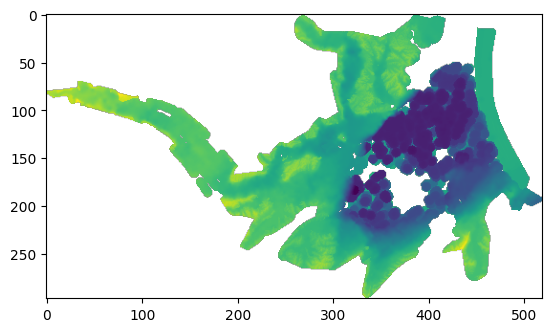

In [30]:
import matplotlib.pyplot as plt

plt.imshow(grid)

In [ ]:

# create surface map
index_ds = skytem_to_xarray(clipped_df, i_value='CC', res=RESOLUTION).isel({'zc': -150})

#replace nan with 0
index_ds = index_ds.fillna(0)